## Loading Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, recall_score,
                             precision_score, precision_recall_curve, roc_auc_score, roc_curve, auc)
import optuna

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

In [2]:
# Get project root (parent of notebooks directory)
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.database.engine import get_db_engine

engine = get_db_engine()

Database connection successful!


In [3]:
df = pd.read_sql("SELECT * FROM Gold.Fact_Orders", engine).drop(columns = ['order_id', 'customer_unique_id',
                                                                           'purchase_date_key', 'load_date_timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_status          99441 non-null  object 
 1   total_payment         99440 non-null  float64
 2   primary_payment_type  99440 non-null  object 
 3   review_score          65049 non-null  float64
 4   review_text           26816 non-null  object 
 5   delivery_days_actual  96476 non-null  float64
 6   is_late_delivery      96476 non-null  object 
 7   is_invalid_payment    99441 non-null  bool   
dtypes: bool(1), float64(3), object(4)
memory usage: 5.4+ MB


## Text Preprocessing using spaCy

In [4]:
df = df.dropna(subset = 'review_text').dropna().reset_index(drop = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25625 entries, 0 to 25624
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_status          25625 non-null  object 
 1   total_payment         25625 non-null  float64
 2   primary_payment_type  25625 non-null  object 
 3   review_score          25625 non-null  float64
 4   review_text           25625 non-null  object 
 5   delivery_days_actual  25625 non-null  float64
 6   is_late_delivery      25625 non-null  object 
 7   is_invalid_payment    25625 non-null  bool   
dtypes: bool(1), float64(3), object(4)
memory usage: 1.4+ MB


In [5]:
# Loading Portuguese model
nlp = spacy.load('pt_core_news_lg')

def refine_review(text):
    # Initialization the spaCy document
    doc = nlp(text)
    
    # Keeping only these
    important_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
    
    # List comprehensing the processed text
    clean_tokens = [
        token.lemma_.lower()                            # Lemmatization
        for token in doc                                # Iterating through tokens
        if (not token.is_stop or token.text == 'não')   # Removing stop words but keeping negation (não)
        and token.pos_ in important_tags                # Keeping important POS
        and len(token.text) > 2                         # Removing insignifacant noise
    ]
    
    return " ".join(clean_tokens)
    
    
score_map = {1: 0, 2: 0, 3: 0,  # Negative
             4: 1, 5: 1}        # Positive

In [6]:
df['review_score'] = df['review_score'].map(score_map)
df['review_text'] = df['review_text'].apply(refine_review)
df = df[df['review_text'].str.strip() != ""]
df

,order_status,total_payment,primary_payment_type,review_score,review_text,delivery_days_actual,is_late_delivery,is_invalid_payment
0,delivered,72.19,credit card,1,perfeito produto entregar combinado,7.0,False,False
1,delivered,216.87,credit card,1,chegar prazo prever produto surpreender qualid...,8.0,False,False
2,delivered,218.04,credit card,1,gostar vir prazo determinar,25.0,False,False
3,delivered,68.87,credit card,1,caixa produto vir pequeno avariação resto vir ...,5.0,False,False
4,delivered,97.32,credit card,1,excelente serviço compra,7.0,False,False
...,...,...,...,...,...,...,...,...
25619,delivered,163.24,credit card,1,recomendar lojameu produto chegar prazo perfei...,12.0,False,False
25620,delivered,162.10,boleto,0,produto chegar corretamente haver demora demas...,21.0,True,False
25621,delivered,55.04,boleto,1,amer comprar baratheon receber produto prazo e...,8.0,False,False
25623,delivered,15.86,credit card,0,compra fazer mes recebi produto necessidade pr...,35.0,True,False


$$TF=\frac{\text{Frequency of a word in the document}}{\text{Total words in the document}}$$

$$IDF = \log\left({\frac{\text{Total number of docs}}{\text{Number of docs containing the words}}}\right)$$

## Modeling

In [7]:
bool_encoder = FunctionTransformer(lambda X: (X.astype(str) == 'True').astype(int))

preprocessor = ColumnTransformer(transformers = [
    ('ohe', OneHotEncoder(drop = 'first', sparse_output = False), ['primary_payment_type', 'order_status']),
    ('scaler', RobustScaler(), ['delivery_days_actual', 'total_payment']),
    ('vectorizer', TfidfVectorizer(ngram_range= (1, 2), min_df = 7, max_df = .8), 'review_text'),
    ('bools', bool_encoder, ['is_late_delivery', 'is_invalid_payment'])
], remainder = 'passthrough')

In [8]:
X = df.drop(columns = 'review_score')
y = df['review_score']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = .2,
                                                    stratify = y, random_state = 30)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (19567, 7)
X_test shape: (4892, 7)


In [11]:
# CONFIG
random_state = 30
n_splits     = 5
n_trials     = 50
scoring      = "f1_macro"
thresholds = [.2, .25, .3, .35, .4, .45, .5]
results    = []

skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = random_state)

# Each model block writes its proba here
test_proba = {}

### Logistic Regression

In [ ]:
def objective_lgr(trial):
    max_features = trial.suggest_int('preprocessor__vectorizer__max_features', 500, 2500, step = 500)
    lgr_params = {'classifier__C': trial.suggest_float('classifier__C', 0.01, 10.0, log=True),
                  'classifier__max_iter': trial.suggest_int('classifier__max_iter', 1000, 3000),
                  'classifier__class_weight': trial.suggest_categorical('classifier__class_weight', ['balanced', None])}
    
    ml_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state = random_state))
    ])
    
    ml_pipeline.set_params(
        preprocessor__vectorizer__max_features = max_features,
        **lgr_params
    )
    
    scores = cross_val_score(ml_pipeline, X_train, y_train,
                             cv = skf, scoring = scoring, n_jobs = 1)
    
    if np.isnan(scores).any():
        return 0.0
    return scores.mean() - (scores.std() * .5)

study_lgr = optuna.create_study(direction = 'maximize')
study_lgr.optimize(objective_lgr, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_lgr.best_value:.3f}")
print(f"  Best params      : {study_lgr.best_params}")

lgr_best = ml_pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(random_state = random_state))
])
lgr_best.set_params(**study_lgr.best_params)
lgr_best.fit(X_train, y_train)

lr_proba = lgr_best.predict_proba(X_test)
lr_pred = lgr_best.predict(X_test)

test_proba["Logistic Regression"] = lr_proba[:, 0]   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, lr_pred, digits = 2))
print("-"*55)

[I 2026-05-09 12:24:46,788] A new study created in memory with name: no-name-5c1f5aa7-d464-4ade-875d-b974cd9f68a5
Best trial: 0. Best value: 0.870334:   2%|▏         | 1/50 [00:02<01:52,  2.30s/it]

[I 2026-05-09 12:24:49,084] Trial 0 finished with value: 0.8703340329033963 and parameters: {'preprocessor__vectorizer__max_features': 1500, 'classifier__C': 0.9137054165340855, 'classifier__max_iter': 2081, 'classifier__class_weight': None}. Best is trial 0 with value: 0.8703340329033963.


Best trial: 0. Best value: 0.870334:   4%|▍         | 2/50 [00:04<01:41,  2.11s/it]

[I 2026-05-09 12:24:51,059] Trial 1 finished with value: 0.7306646772289085 and parameters: {'preprocessor__vectorizer__max_features': 2500, 'classifier__C': 0.024746881325639302, 'classifier__max_iter': 2185, 'classifier__class_weight': None}. Best is trial 0 with value: 0.8703340329033963.


Best trial: 0. Best value: 0.870334:   6%|▌         | 3/50 [00:06<01:38,  2.09s/it]

...

[I 2026-05-09 12:26:31,257] Trial 47 finished with value: 0.8657781661783721 and parameters: {'preprocessor__vectorizer__max_features': 2000, 'classifier__C': 6.403381206933881, 'classifier__max_iter': 2999, 'classifier__class_weight': 'balanced'}. Best is trial 26 with value: 0.8718905628086802.


Best trial: 26. Best value: 0.871891:  98%|█████████▊| 49/50 [01:46<00:02,  2.42s/it]

[I 2026-05-09 12:26:33,768] Trial 48 finished with value: 0.8695329242215992 and parameters: {'preprocessor__vectorizer__max_features': 2000, 'classifier__C': 3.2281253912184638, 'classifier__max_iter': 2495, 'classifier__class_weight': 'balanced'}. Best is trial 26 with value: 0.8718905628086802.


Best trial: 26. Best value: 0.871891: 100%|██████████| 50/50 [01:49<00:00,  2.19s/it]


[I 2026-05-09 12:26:36,213] Trial 49 finished with value: 0.8714601722458596 and parameters: {'preprocessor__vectorizer__max_features': 2000, 'classifier__C': 2.0232548454813624, 'classifier__max_iter': 2666, 'classifier__class_weight': 'balanced'}. Best is trial 26 with value: 0.8718905628086802.

✔ Best CV f1_macro : 0.872
  Best params      : {'preprocessor__vectorizer__max_features': 2000, 'classifier__C': 1.7787993077521633, 'classifier__max_iter': 2962, 'classifier__class_weight': 'balanced'}

-------------------------------------------------------
  Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1655
           1       0.94      0.89      0.91      3237

    accuracy                           0.89      4892
   macro avg       0.87      0.89      0.88      4892
weighted avg       0.89      0.89      0.89      4892

-------------------------------------------------------


### Naive Bayes

In [ ]:
# Returning a Dense dataframe
def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else X


def objective_nb(trial):
    max_features = trial.suggest_int('preprocessor__vectorizer__max_features', 500, 2500, step = 500)
    nb_params = {
        'classifier__var_smoothing': trial.suggest_float('classifier__var_smoothing', 1e-12, 1e-6, log = True)
    }
    
    ml_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('to_dense', FunctionTransformer(to_dense, accept_sparse = True)),
        ('classifier', GaussianNB())
    ])
    
    ml_pipeline.set_params(
        preprocessor__vectorizer__max_features = max_features,
        **nb_params
    )
    
    scores = cross_val_score(ml_pipeline, X_train, y_train,
                             cv = skf, scoring = scoring, n_jobs = 1)
    
    if np.isnan(scores).any():
        return 0.0
    return scores.mean() - (scores.std() * .5)

study_nb = optuna.create_study(direction = 'maximize')
study_nb.optimize(objective_nb, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_nb.best_value:.3f}")
print(f"  Best params      : {study_nb.best_params}")

nb_best = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('to_dense', FunctionTransformer(to_dense, accept_sparse = True)),
        ('classifier', GaussianNB())
])
nb_best.set_params(**study_nb.best_params)
nb_best.fit(X_train, y_train)

nb_proba = nb_best.predict_proba(X_test)
nb_pred = nb_best.predict(X_test)

test_proba["Naive Bayes"] = nb_proba[:, 0]   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, nb_pred, digits = 2))
print("-"*55)

[I 2026-05-09 12:30:27,896] A new study created in memory with name: no-name-895dea0f-2acd-4a09-9cc1-ea809b8b18c3
Best trial: 0. Best value: 0.827528:   2%|▏         | 1/50 [00:03<02:50,  3.48s/it]

[I 2026-05-09 12:30:31,373] Trial 0 finished with value: 0.8275283410568846 and parameters: {'preprocessor__vectorizer__max_features': 1000, 'classifier__var_smoothing': 1.428038250717558e-12}. Best is trial 0 with value: 0.8275283410568846.


Best trial: 1. Best value: 0.836648:   4%|▍         | 2/50 [00:06<02:42,  3.39s/it]

[I 2026-05-09 12:30:34,696] Trial 1 finished with value: 0.8366480244595483 and parameters: {'preprocessor__vectorizer__max_features': 1000, 'classifier__var_smoothing': 1.6824963249698616e-11}. Best is trial 1 with value: 0.8366480244595483.


Best trial: 2. Best value: 0.842734:   6%|▌         | 3/50 [00:10<02:56,  3.76s/it]

...

[I 2026-05-09 12:33:41,379] Trial 47 finished with value: 0.8422239487223684 and parameters: {'preprocessor__vectorizer__max_features': 1000, 'classifier__var_smoothing': 9.712428329982627e-07}. Best is trial 44 with value: 0.8429428476646886.


Best trial: 44. Best value: 0.842943:  98%|█████████▊| 49/50 [03:18<00:04,  4.05s/it]

[I 2026-05-09 12:33:46,187] Trial 48 finished with value: 0.838299840125155 and parameters: {'preprocessor__vectorizer__max_features': 2000, 'classifier__var_smoothing': 1.938711338228217e-08}. Best is trial 44 with value: 0.8429428476646886.


Best trial: 49. Best value: 0.842993: 100%|██████████| 50/50 [03:22<00:00,  4.04s/it]


[I 2026-05-09 12:33:50,133] Trial 49 finished with value: 0.8429926829667858 and parameters: {'preprocessor__vectorizer__max_features': 1500, 'classifier__var_smoothing': 2.8607907034512706e-07}. Best is trial 49 with value: 0.8429926829667858.

✔ Best CV f1_macro : 0.843
  Best params      : {'preprocessor__vectorizer__max_features': 1500, 'classifier__var_smoothing': 2.8607907034512706e-07}

-------------------------------------------------------
  Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1655
           1       0.92      0.86      0.89      3237

    accuracy                           0.86      4892
   macro avg       0.84      0.86      0.85      4892
weighted avg       0.87      0.86      0.86      4892

-------------------------------------------------------


### Model Comparison

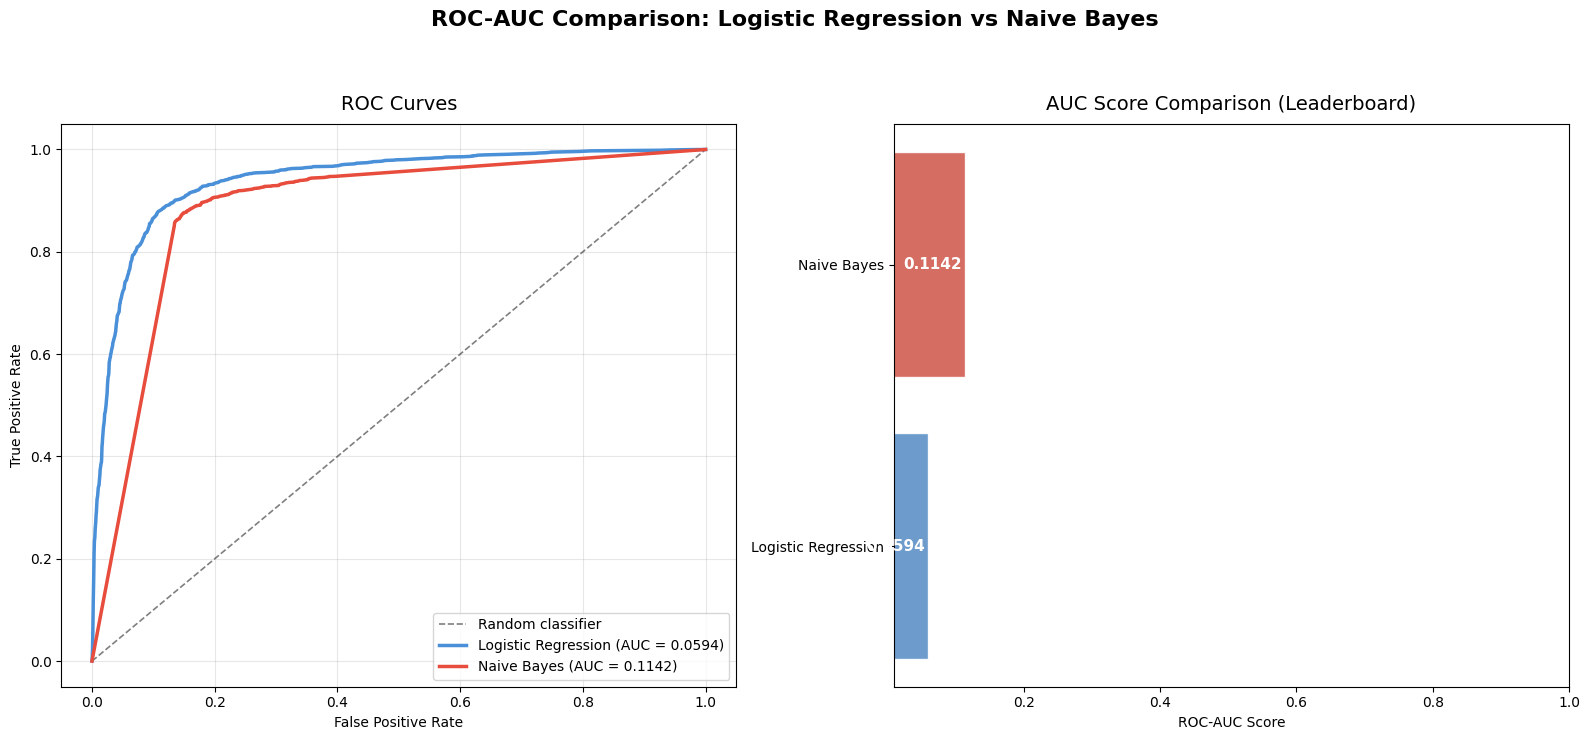


═════════════════════════════════════════════
RANK  MODEL                     TEST AUC  
─────────────────────────────────────────────
1     Naive Bayes               0.1142     ⭐
2     Logistic Regression       0.0594       
═════════════════════════════════════════════


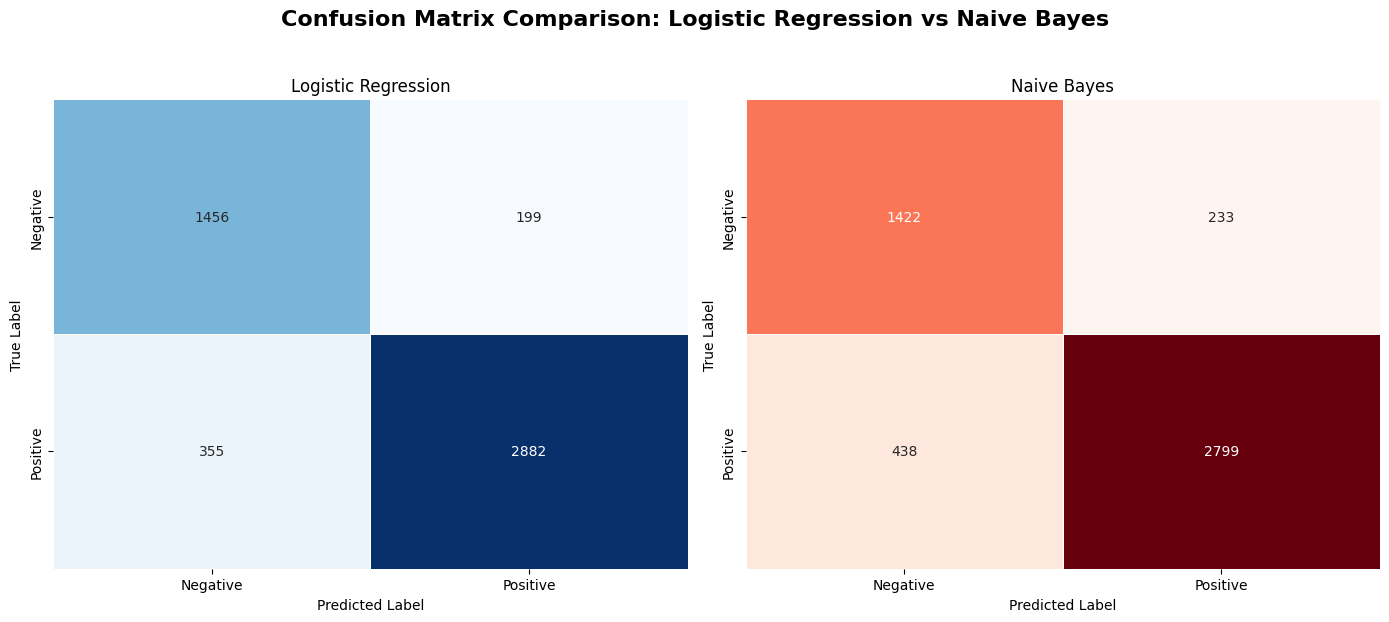

In [24]:
COLORS = {
    "Logistic Regression": "#4A90D9",
    "Naive Bayes": "#E74C3C",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC-AUC Comparison: Logistic Regression vs Naive Bayes", 
             fontsize=16, fontweight="bold", y=1.05)

ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier", alpha=0.5)

rows = []
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    score = auc(fpr, tpr)
    rows.append({"Model": name, "AUC": score})
    
    sns.lineplot(x=tpr, y=fpr, ax=ax, lw=2.5, color=COLORS.get(name, "#333333"),
                 label=f"{name} (AUC = {score:.4f})")

ax.set_title("ROC Curves", fontsize=14, pad=10)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=True)

ax2 = axes[1]
df_aucs = pd.DataFrame(rows).sort_values("AUC", ascending=False)

sns.barplot(data=df_aucs, x='AUC', y='Model', palette=COLORS, 
            ax=ax2, hue='Model', legend=False, alpha=0.9, edgecolor="white")

for i, val in enumerate(df_aucs['AUC']):
    ax2.text(val - 0.005, i, f"{val:.4f}", va='center', ha='right', 
             color='white', fontweight='bold', fontsize=11)

ax2.set_title("AUC Score Comparison (Leaderboard)", fontsize=14, pad=10)

min_auc = df_aucs['AUC'].min()
ax2.set_xlim([max(0, min_auc - 0.05), 1.0])
ax2.set_xlabel("ROC-AUC Score")
ax2.set_ylabel("") 

plt.tight_layout()
plt.show()

print("\n" + "═"*45)
print(f"{'RANK':<5} {'MODEL':<25} {'TEST AUC':<10}")
print("─" * 45)
for i, row in enumerate(df_aucs.itertuples(), 1):
    star = "⭐" if i == 1 else "  "
    print(f"{i:<5} {row.Model:<25} {row.AUC:<10.4f} {star}")
print("═"*45)

# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrix Comparison: Logistic Regression vs Naive Bayes", 
             fontsize=16, fontweight="bold", y=1.03)

lr_cm = confusion_matrix(y_test, lr_pred)
nb_cm = confusion_matrix(y_test, nb_pred)
labels = ["Negative", "Positive"]

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[1], linewidths=0.5, linecolor='white')
axes[1].set_title("Naive Bayes")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Feature importance

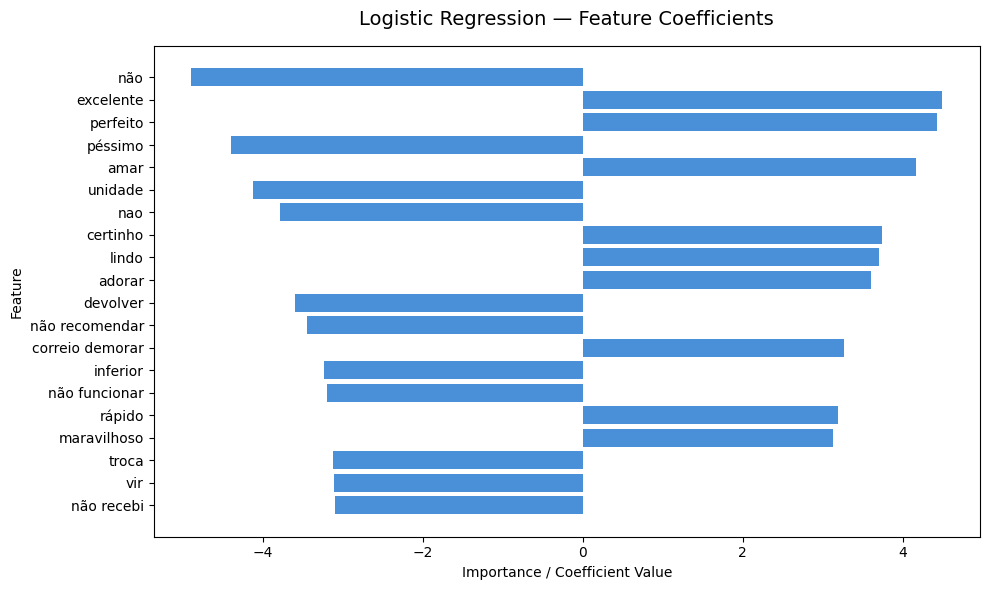

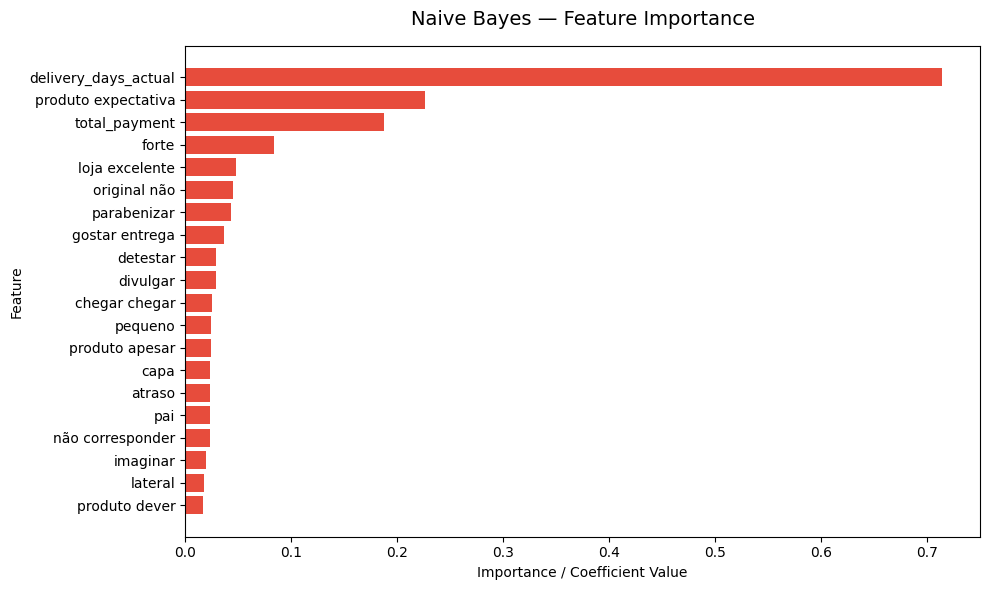

In [ ]:
def plot_feature_importance(importances, feature_names, title, color, top_n=20):
    feature_names = np.asarray(feature_names)
    importances = np.asarray(importances)

    limit = min(len(feature_names), len(importances))
    feature_names = feature_names[:limit]
    importances = importances[:limit]

    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
    df_imp = df_imp.reindex(df_imp["importance"].abs().sort_values(ascending=False).index)
    df_imp = df_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color=color)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Importance / Coefficient Value")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()


def get_preprocessor_feature_names(fitted_preprocessor):
    feature_names = []

    for name, transformer, columns in fitted_preprocessor.transformers_:
        if name == 'remainder' and transformer == 'passthrough':
            feature_names.extend(list(columns))
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            try:
                feature_names.extend(transformer.get_feature_names_out(columns))
            except TypeError:
                feature_names.extend(transformer.get_feature_names_out())
        else:
            if isinstance(columns, (list, tuple, np.ndarray)):
                feature_names.extend(list(columns))
            else:
                feature_names.append(columns)

    return np.asarray(feature_names, dtype=object)


feature_names = get_preprocessor_feature_names(lgr_best.named_steps['preprocessor'])

plot_feature_importance(
    importances   = lgr_best.named_steps['classifier'].coef_[0],
    feature_names = feature_names,
    title         = "Logistic Regression — Feature Coefficients",
    color         = "#4A90D9"
)

nb_model = nb_best.named_steps['classifier']
nb_feature_importance = np.abs(nb_model.theta_[1] - nb_model.theta_[0])

plot_feature_importance(
    importances   = nb_feature_importance,
    feature_names = feature_names,
    title         = "Naive Bayes — Feature Importance",
    color         = "#E74C3C"
)